### What this phase does

Phase 5 synthesises all previous phases into actionable insights and interpretable analysis.

| Section | Method | Goal |
|---------|--------|------|
| **5A — SHAP Analysis** | XGBoost gain importance + per-group breakdown | Which features drive delay predictions globally and per delay class |
| **5B — Feature Importance** | Consolidated ranking across Phase 2 & 3 models | Top delay predictors, consistency across model families |
| **5C — Delay Heatmaps** | Pivot tables: station × hour, station × day | When and where delays are worst |
| **5D — Network Graph** | Station-to-station delay propagation | How severe delays spread along routes |

### What "interpretability" means here
- **Global**: which features matter most on average across all predictions
- **Local**: for a specific stop, which features pushed the prediction up or down
- **Temporal**: delay patterns by hour, day of week, month
- **Spatial**: delay hotspots by station and route

### Prerequisites
Phase 1 → `outputs/db_train.parquet`, `outputs/db_test.parquet`, `outputs/config.json`  
Phase 2 → `outputs/phase2_config.json`, `outputs/phase2_predictions.parquet`, `outputs/models/p2_xgb.pkl`  
Phase 3 → `outputs/phase3_config.json`, `outputs/phase3_shap_importance.csv`, `outputs/models/p3_xgb.pkl`  
Phase 4 → `outputs/phase4_config.json`, `outputs/phase4_sequence_predictions.parquet`, `outputs/phase4_cluster_summary.csv`

In [2]:
# ════════════════════════════════════════════════════════════
# CELL 1 · IMPORTS
# ════════════════════════════════════════════════════════════

import warnings, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from IPython.display import display

warnings.filterwarnings("ignore")
np.random.seed(42)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Paths ──────────────────────────────────────────────────
OUTPUT_DIR = Path("outputs")
FIG_DIR    = OUTPUT_DIR / "figures"
MODEL_DIR  = OUTPUT_DIR / "models"
FIG_DIR.mkdir(exist_ok=True)

# ── Plot style — consistent with all previous phases ────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PAL     = sns.color_palette("muted", 12)
FIG_DPI = 150

CLASS_LABELS = {
    0: "On time/early",
    1: "Slight (1-5m)",
    2: "Moderate (6-15m)",
    3: "Severe (>15m)",
}

print("✅  Phase 5 imports ready.")

✅  Phase 5 imports ready.


In [3]:
# ════════════════════════════════════════════════════════════
# CELL 2 · LOAD ALL PREVIOUS PHASE OUTPUTS
# ════════════════════════════════════════════════════════════

# ── Raw data ──────────────────────────────────────────────────
df_train = pd.read_parquet(OUTPUT_DIR / "db_train.parquet")
df_test  = pd.read_parquet(OUTPUT_DIR / "db_test.parquet")

# ── Configs ───────────────────────────────────────────────────
with open(OUTPUT_DIR / "config.json") as f:
    cfg = json.load(f)
with open(OUTPUT_DIR / "phase2_config.json") as f:
    p2_cfg = json.load(f)
with open(OUTPUT_DIR / "phase3_config.json") as f:
    p3_cfg = json.load(f)
with open(OUTPUT_DIR / "phase4_config.json") as f:
    p4_cfg = json.load(f)

# ── Feature lists ─────────────────────────────────────────────
FEATURES_TREE       = [f for f in cfg["FEATURES_TREE"]   if f in df_train.columns]
FEATURES_LINEAR     = [f for f in cfg["FEATURES_LINEAR"] if f in df_train.columns]
WEATHER_FEATURES    = cfg["WEATHER_FEATURES"]
LAG_FEATURES        = cfg["LAG_FEATURES"]
CONGESTION_FEATURES = cfg["CONGESTION_FEATURES"]
TARGET              = cfg["TARGET_REG"]   # "delay_in_min"

# ── Phase 2 predictions ───────────────────────────────────────
df_p2_pred = pd.read_parquet(OUTPUT_DIR / "phase2_predictions.parquet")
# Parse datetime if needed
if df_p2_pred["departure_planned_time"].dtype == object:
    df_p2_pred["departure_planned_time"] = pd.to_datetime(
        df_p2_pred["departure_planned_time"]
    )

# ── Phase 4 outputs ───────────────────────────────────────────
df_seq_pred = pd.read_parquet(OUTPUT_DIR / "phase4_sequence_predictions.parquet")
df_anomaly  = pd.read_parquet(OUTPUT_DIR / "phase4_anomaly_results.parquet")

# ── Phase 3 SHAP importance (gain-based) ─────────────────────
shap_imp_path = OUTPUT_DIR / "phase3_shap_importance.csv"
if shap_imp_path.exists():
    df_shap = pd.read_csv(shap_imp_path)
else:
    df_shap = None
    print("⚠️  phase3_shap_importance.csv not found — SHAP section will use XGBoost gain directly")

# ── Cluster summary ───────────────────────────────────────────
cluster_path = OUTPUT_DIR / "phase4_cluster_summary.csv"
GEO_AVAILABLE = cluster_path.exists() and p4_cfg.get("geo_available", False)
if GEO_AVAILABLE:
    df_clusters = pd.read_csv(cluster_path, index_col=0)

# ── Summary printout ──────────────────────────────────────────
print(f"Train rows    : {len(df_train):,}")
print(f"Test rows     : {len(df_test):,}")
print(f"Tree features : {len(FEATURES_TREE)}")
print(f"\nPhase 2 best  : {p2_cfg['best_model_name']}  MAE={p2_cfg['best_mae']:.4f} min")
print(f"Phase 3 best  : {p3_cfg['best_model_name']}  Macro F1={p3_cfg['best_macro_f1']:.4f}")
print(f"Phase 4 LSTM  : MAE={p4_cfg['lstm_mae']:.4f} min  R2={p4_cfg['lstm_r2']:.4f}")
print(f"Phase 4 Transf: MAE={p4_cfg['transformer_mae']:.4f} min  R2={p4_cfg['transformer_r2']:.4f}")
print(f"Phase 4 Anomalies: {p4_cfg['pct_anomalies_test']:.1f}% of test stops")
print(f"Geo available : {GEO_AVAILABLE}")


Train rows    : 715,232
Test rows     : 178,310
Tree features : 60

Phase 2 best  : MLP Neural Network  MAE=0.9130 min
Phase 3 best  : LightGBM  Macro F1=0.7793
Phase 4 LSTM  : MAE=0.9620 min  R2=0.8264
Phase 4 Transf: MAE=0.9569 min  R2=0.8258
Phase 4 Anomalies: 5.4% of test stops
Geo available : True


In [4]:
# ════════════════════════════════════════════════════════════
# CELL 5A-1 · CONSOLIDATED FEATURE IMPORTANCE
#
# We consolidate feature importance from three sources:
#   1. XGBoost (Phase 2 regressor) — gain importance
#   2. XGBoost (Phase 3 classifier) — gain importance
#   3. LightGBM (Phase 3 classifier) — split importance
#
# Features that rank highly in ALL three are the most
# trustworthy predictors of delay — not model-specific artefacts.
#
# We use the sklearn feature_importances_ attribute which is
# already correctly aligned to FEATURES_TREE by index position
# (avoids the f0/f1 naming issue encountered in Phase 3).
# ════════════════════════════════════════════════════════════

print("=" * 72)
print("  5A — CONSOLIDATED FEATURE IMPORTANCE")
print("=" * 72)

# ── Load saved models ─────────────────────────────────────────
p2_xgb_path  = MODEL_DIR / "p2_xgb.pkl"
p3_xgb_path  = MODEL_DIR / "p3_xgb.pkl"
p3_lgbm_path = MODEL_DIR / "p3_lgbm.pkl"

models_loaded = {}
for name, path in [("XGB-Reg (P2)", p2_xgb_path),
                   ("XGB-Clf (P3)", p3_xgb_path),
                   ("LGBM-Clf (P3)", p3_lgbm_path)]:
    if path.exists():
        models_loaded[name] = joblib.load(path)
        print(f"  Loaded : {name}  ({path.name})")
    else:
        print(f"  ⚠️  Not found: {path.name}  — will skip")

# ── Build aligned importance DataFrame ───────────────────────
def get_importance(model, feature_names):
    """Extract feature_importances_ and normalise to [0, 1]."""
    raw = model.feature_importances_
    mn, mx = raw.min(), raw.max()
    norm = (raw - mn) / (mx - mn + 1e-12)
    return pd.Series(norm, index=feature_names)

imp_series = {}
for name, model in models_loaded.items():
    imp_series[name] = get_importance(model, FEATURES_TREE)

if not imp_series:
    print("❌  No models loaded — cannot build importance comparison.")
else:
    imp_df = pd.DataFrame(imp_series).fillna(0)
    imp_df["mean_importance"] = imp_df.mean(axis=1)
    imp_df = imp_df.sort_values("mean_importance", ascending=False)

    # Feature group labels
    def feat_group(f):
        if f in LAG_FEATURES:           return "Lag"
        elif f in CONGESTION_FEATURES:  return "Congestion"
        elif f in WEATHER_FEATURES:     return "Weather"
        elif f in ["lat", "lon", "weather_cell"]: return "Geo"
        elif f in ["stop_number", "is_terminus",
                   "is_first_stop", "planned_dwell_min"]: return "Route"
        elif f.startswith("station_"):  return "Station"
        elif f.startswith("traintype_"): return "Train type"
        elif f.endswith("_enc"):        return "Encoded ID"
        else:                           return "Temporal"

    GROUP_COLORS = {
        "Lag"        : "#e07b3a",
        "Congestion" : "#8e5ea2",
        "Weather"    : "#3a9e6a",
        "Geo"        : "#5b9bd5",
        "Route"      : "#f0c050",
        "Station"    : "#c05050",
        "Train type" : "#70b070",
        "Encoded ID" : "#aaaaaa",
        "Temporal"   : "#6699cc",
    }

    imp_df["group"] = [feat_group(f) for f in imp_df.index]
    print(f"\nTop 20 features by mean normalised importance (across models):")
    print(imp_df[["mean_importance","group"] + list(imp_series.keys())].head(20).round(4).to_string())


  5A — CONSOLIDATED FEATURE IMPORTANCE
  Loaded : XGB-Reg (P2)  (p2_xgb.pkl)
  Loaded : XGB-Clf (P3)  (p3_xgb.pkl)
  Loaded : LGBM-Clf (P3)  (p3_lgbm.pkl)

Top 20 features by mean normalised importance (across models):
                               mean_importance       group  XGB-Reg (P2)  XGB-Clf (P3)  LGBM-Clf (P3)
prev_stop_was_delayed                   0.6689         Lag        1.0000        1.0000         0.0068
prev_stop_delay                         0.4667         Lag        0.3343        0.5938         0.4719
final_destination_station_enc           0.3358  Encoded ID        0.0024        0.0049         1.0000
delay_rolling3                          0.3346         Lag        0.2273        0.1607         0.6157
temp                                    0.3277     Weather        0.0022        0.0050         0.9760
minute                                  0.3257    Temporal        0.0023        0.0042         0.9707
congestion_ratio                        0.2805  Congestion        0

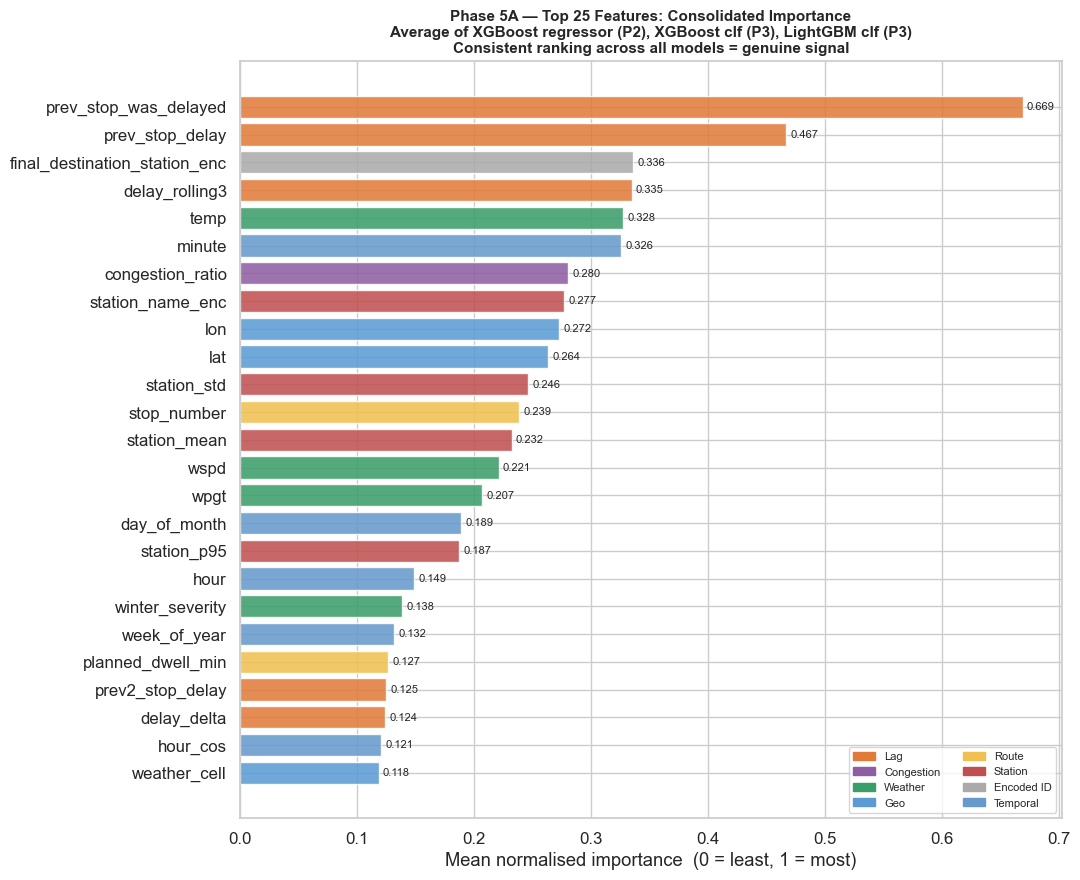

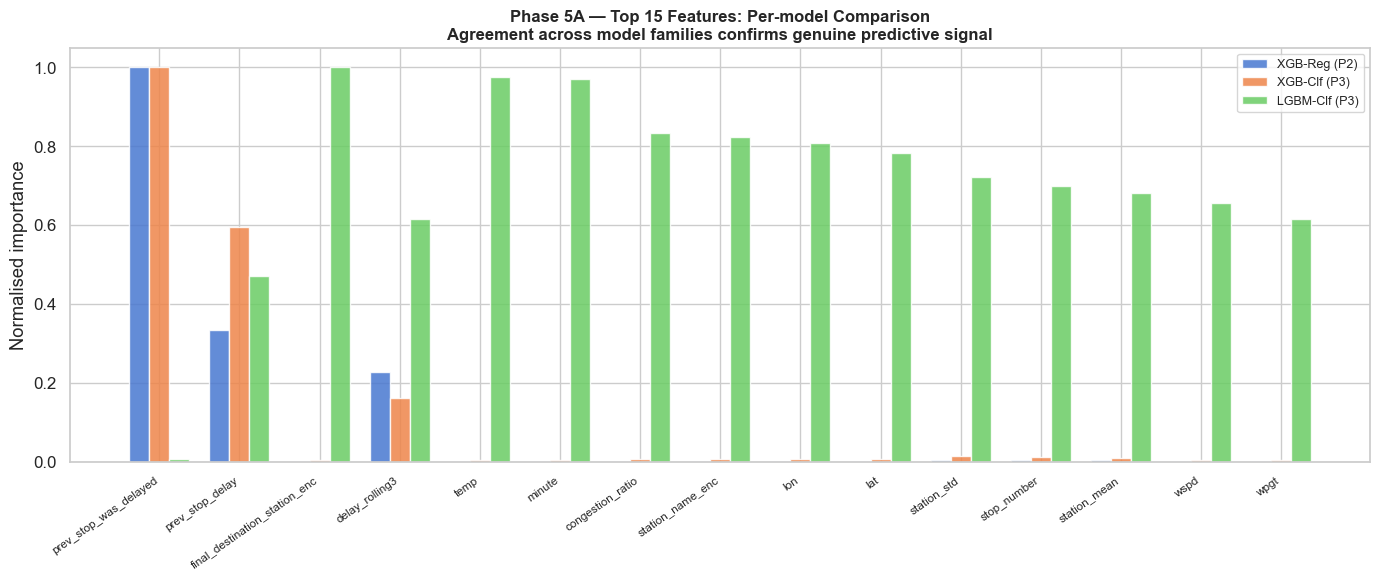

In [5]:
# ════════════════════════════════════════════════════════════
# CELL 5A-CHART 1 · CONSOLIDATED IMPORTANCE CHART
# ════════════════════════════════════════════════════════════

if imp_series:
    top_n  = 25
    top_df = imp_df.head(top_n).copy()
    bar_colors = [GROUP_COLORS.get(g, PAL[0]) for g in top_df["group"]]

    fig, ax = plt.subplots(figsize=(11, 9))
    bars = ax.barh(
        top_df.index[::-1],
        top_df["mean_importance"][::-1],
        color=bar_colors[::-1],
        alpha=0.87,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_xlabel("Mean normalised importance  (0 = least, 1 = most)")
    ax.set_title(
        "Phase 5A — Top 25 Features: Consolidated Importance\n"
        "Average of XGBoost regressor (P2), XGBoost clf (P3), LightGBM clf (P3)\n"
        "Consistent ranking across all models = genuine signal",
        fontsize=11, fontweight="bold"
    )

    # Legend for groups
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(color=c, label=g)
        for g, c in GROUP_COLORS.items()
        if g in top_df["group"].values
    ]
    ax.legend(handles=legend_handles, fontsize=8, loc="lower right", ncol=2)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "p5_01_consolidated_importance.png",
                dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

    # ── Side-by-side model comparison (top 15) ───────────────
    top15 = imp_df.head(15).copy()
    model_cols = list(imp_series.keys())
    n_models   = len(model_cols)
    x          = np.arange(15)
    width      = 0.25
    offsets    = np.linspace(-(n_models-1)*width/2, (n_models-1)*width/2, n_models)

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, col in enumerate(model_cols):
        ax.bar(x + offsets[i], top15[col], width,
               label=col, color=PAL[i], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(top15.index, rotation=35, ha="right", fontsize=8.5)
    ax.set_ylabel("Normalised importance")
    ax.set_title(
        "Phase 5A — Top 15 Features: Per-model Comparison\n"
        "Agreement across model families confirms genuine predictive signal",
        fontsize=12, fontweight="bold"
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "p5_02_importance_per_model.png",
                dpi=FIG_DPI, bbox_inches="tight")
    plt.show()


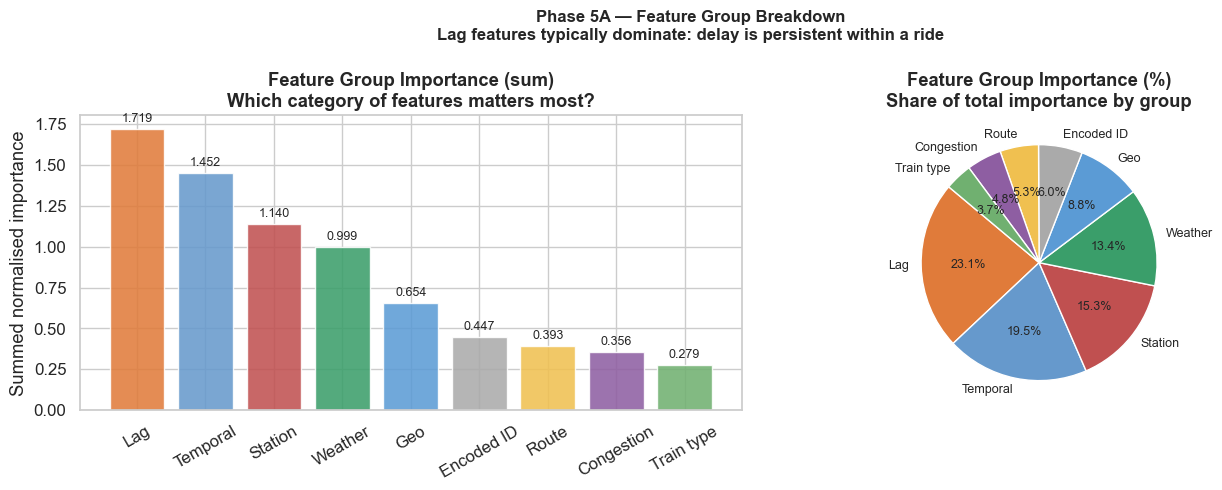


Feature group importance summary:
  Lag            : 1.7194  (5 features)
  Temporal       : 1.4519  (17 features)
  Station        : 1.1396  (7 features)
  Weather        : 0.9992  (15 features)
  Geo            : 0.6543  (3 features)
  Encoded ID     : 0.4466  (2 features)
  Route          : 0.3930  (4 features)
  Congestion     : 0.3559  (2 features)
  Train type     : 0.2785  (5 features)


In [6]:
# ════════════════════════════════════════════════════════════
# CELL 5A-CHART 2 · FEATURE GROUP IMPORTANCE BREAKDOWN
#
# Aggregate mean importance by feature group.
# Answers: "which category of features matters most overall?"
# ════════════════════════════════════════════════════════════

if imp_series:
    group_imp = (
        imp_df.groupby("group")["mean_importance"]
        .sum()
        .sort_values(ascending=False)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    group_colors_ordered = [GROUP_COLORS.get(g, "#cccccc") for g in group_imp.index]
    bars = axes[0].bar(group_imp.index, group_imp.values,
                       color=group_colors_ordered, alpha=0.87)
    axes[0].bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
    axes[0].set_ylabel("Summed normalised importance")
    axes[0].set_title("Feature Group Importance (sum)\n"
                      "Which category of features matters most?",
                      fontweight="bold")
    axes[0].tick_params(axis="x", rotation=30)

    # Pie chart
    wedge_colors = [GROUP_COLORS.get(g, "#cccccc") for g in group_imp.index]
    axes[1].pie(
        group_imp.values,
        labels=group_imp.index,
        colors=wedge_colors,
        autopct="%1.1f%%",
        startangle=140,
        textprops={"fontsize": 9},
    )
    axes[1].set_title("Feature Group Importance (%)\n"
                      "Share of total importance by group",
                      fontweight="bold")

    plt.suptitle("Phase 5A — Feature Group Breakdown\n"
                 "Lag features typically dominate: delay is persistent within a ride",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "p5_03_group_breakdown.png",
                dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

    # Print group summary
    print("\nFeature group importance summary:")
    for grp, val in group_imp.items():
        n_feats = (imp_df["group"] == grp).sum()
        print(f"  {grp:15s}: {val:.4f}  ({n_feats} features)")


  5B — DELAY HEATMAPS
Top 20 stations by stop count selected for heatmaps.
Total rows for heatmaps: 97,348


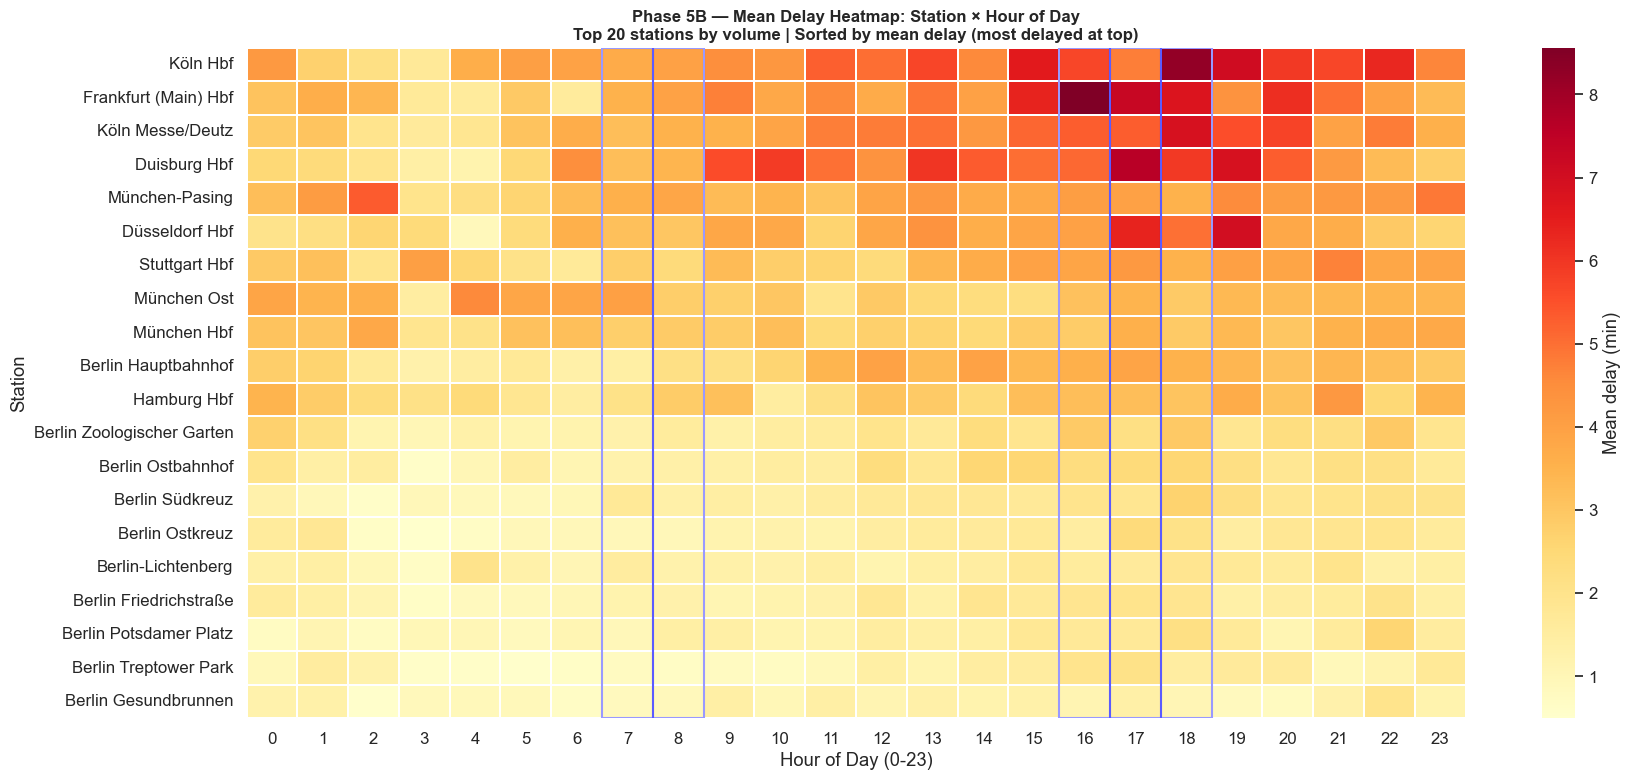

In [7]:
# ════════════════════════════════════════════════════════════
# CELL 5B · DELAY HEATMAPS — STATION × HOUR
#
# We use the full combined dataset (train + test) for heatmaps
# because this is exploratory analysis, not model evaluation.
# The goal is to understand when and where delays are worst.
#
# Three heatmaps:
#   (a) Top 20 stations × hour of day — mean delay
#   (b) Top 20 stations × day of week — mean delay
#   (c) Hour × month — mean delay across all stations
# ════════════════════════════════════════════════════════════

print("=" * 72)
print("  5B — DELAY HEATMAPS")
print("=" * 72)

df_all = pd.concat([df_train, df_test], ignore_index=True)

# ── Require time features ─────────────────────────────────────
for col in ["hour", "day_of_week", "month"]:
    if col not in df_all.columns:
        df_all[col] = pd.to_datetime(df_all["departure_planned_time"]).dt.__getattribute__(
            col if col != "day_of_week" else "dayofweek"
        )

# ── Select top stations by volume (stable estimates) ─────────
TOP_N_STATIONS = 20
top_stations = (
    df_all.groupby("station_name")["delay_in_min"]
    .count()
    .nlargest(TOP_N_STATIONS)
    .index.tolist()
)
df_top = df_all[df_all["station_name"].isin(top_stations)].copy()
print(f"Top {TOP_N_STATIONS} stations by stop count selected for heatmaps.")
print(f"Total rows for heatmaps: {len(df_top):,}")

# ── (a) Station × Hour ────────────────────────────────────────
pivot_sh = (
    df_top.groupby(["station_name", "hour"])["delay_in_min"]
    .mean()
    .unstack(fill_value=0)
)
# Sort stations by their overall mean delay (most delayed at top)
station_order = df_top.groupby("station_name")["delay_in_min"].mean().sort_values(ascending=False).index
pivot_sh = pivot_sh.reindex(station_order)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    pivot_sh,
    cmap       = "YlOrRd",
    ax         = ax,
    linewidths = 0.3,
    annot      = False,
    fmt        = ".1f",
    cbar_kws   = {"label": "Mean delay (min)"},
)
ax.set_xlabel("Hour of Day (0-23)")
ax.set_ylabel("Station")
ax.set_title(
    "Phase 5B — Mean Delay Heatmap: Station × Hour of Day\n"
    f"Top {TOP_N_STATIONS} stations by volume | Sorted by mean delay (most delayed at top)",
    fontsize=12, fontweight="bold"
)
# Rush hour shading
for h in [7, 8, 16, 17, 18]:
    ax.add_patch(plt.Rectangle((h, 0), 1, len(pivot_sh),
                                fill=False, edgecolor="blue", lw=1.5, alpha=0.4))
plt.tight_layout()
plt.savefig(FIG_DIR / "p5_04_heatmap_station_hour.png",
            dpi=FIG_DPI, bbox_inches="tight")
plt.show()


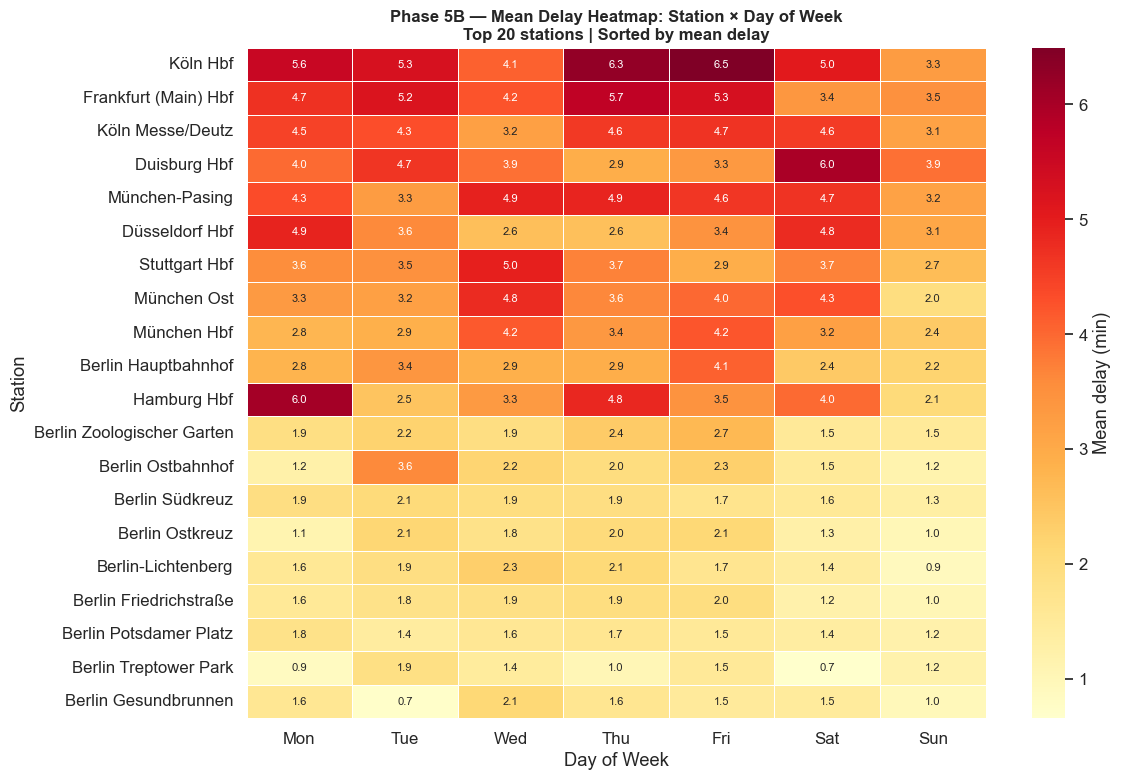

In [8]:
# ════════════════════════════════════════════════════════════
# CELL 5B-CHART 2 · STATION × DAY OF WEEK
# ════════════════════════════════════════════════════════════

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

pivot_sd = (
    df_top.groupby(["station_name", "day_of_week"])["delay_in_min"]
    .mean()
    .unstack(fill_value=0)
)
pivot_sd.columns = [DOW_LABELS[c] for c in pivot_sd.columns]
pivot_sd = pivot_sd.reindex(station_order)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    pivot_sd,
    cmap       = "YlOrRd",
    ax         = ax,
    linewidths = 0.4,
    annot      = True,
    fmt        = ".1f",
    cbar_kws   = {"label": "Mean delay (min)"},
    annot_kws  = {"fontsize": 8},
)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Station")
ax.set_title(
    "Phase 5B — Mean Delay Heatmap: Station × Day of Week\n"
    f"Top {TOP_N_STATIONS} stations | Sorted by mean delay",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(FIG_DIR / "p5_05_heatmap_station_dow.png",
            dpi=FIG_DPI, bbox_inches="tight")
plt.show()


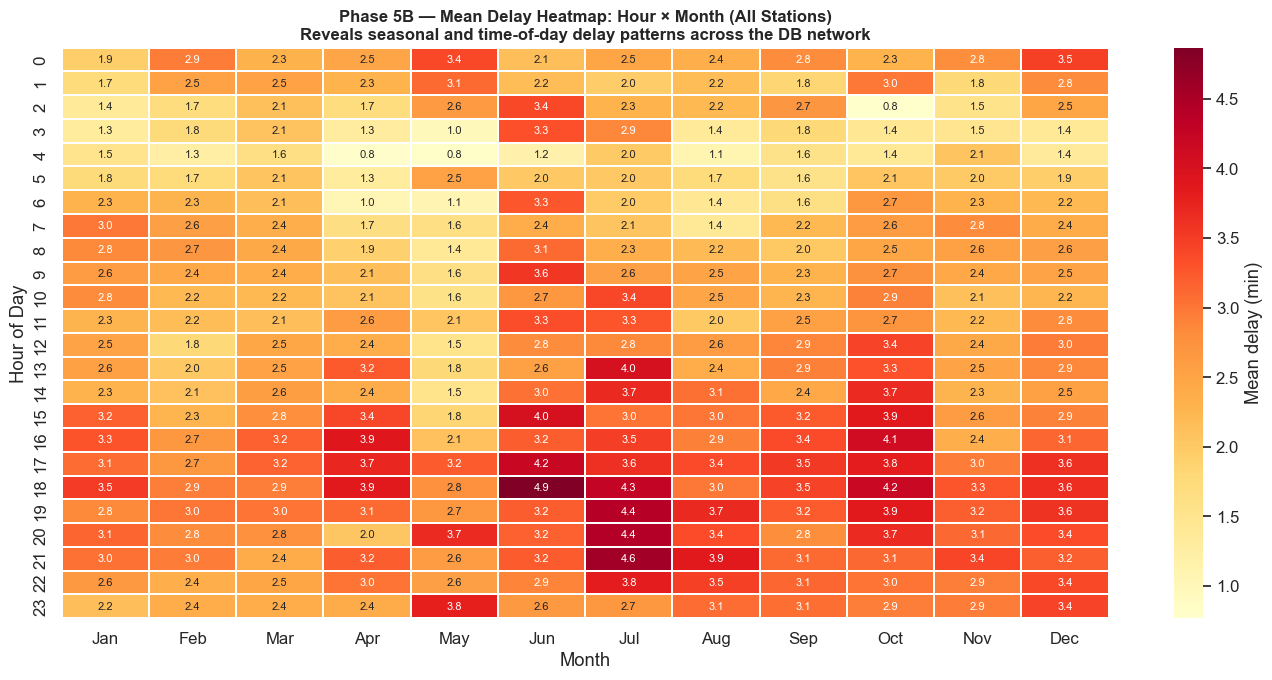

In [9]:
# ════════════════════════════════════════════════════════════
# CELL 5B-CHART 3 · HOUR × MONTH (ALL STATIONS)
# ════════════════════════════════════════════════════════════

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

pivot_hm = (
    df_all.groupby(["hour", "month"])["delay_in_min"]
    .mean()
    .unstack(fill_value=0)
)
if pivot_hm.shape[1] < 12:
    pivot_hm = pivot_hm.reindex(columns=range(1, 13), fill_value=0)
pivot_hm.columns = MONTH_LABELS[: pivot_hm.shape[1]]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot_hm,
    cmap       = "YlOrRd",
    ax         = ax,
    linewidths = 0.3,
    annot      = True,
    fmt        = ".1f",
    cbar_kws   = {"label": "Mean delay (min)"},
    annot_kws  = {"fontsize": 8},
)
ax.set_xlabel("Month")
ax.set_ylabel("Hour of Day")
ax.set_title(
    "Phase 5B — Mean Delay Heatmap: Hour × Month (All Stations)\n"
    "Reveals seasonal and time-of-day delay patterns across the DB network",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(FIG_DIR / "p5_06_heatmap_hour_month.png",
            dpi=FIG_DPI, bbox_inches="tight")
plt.show()


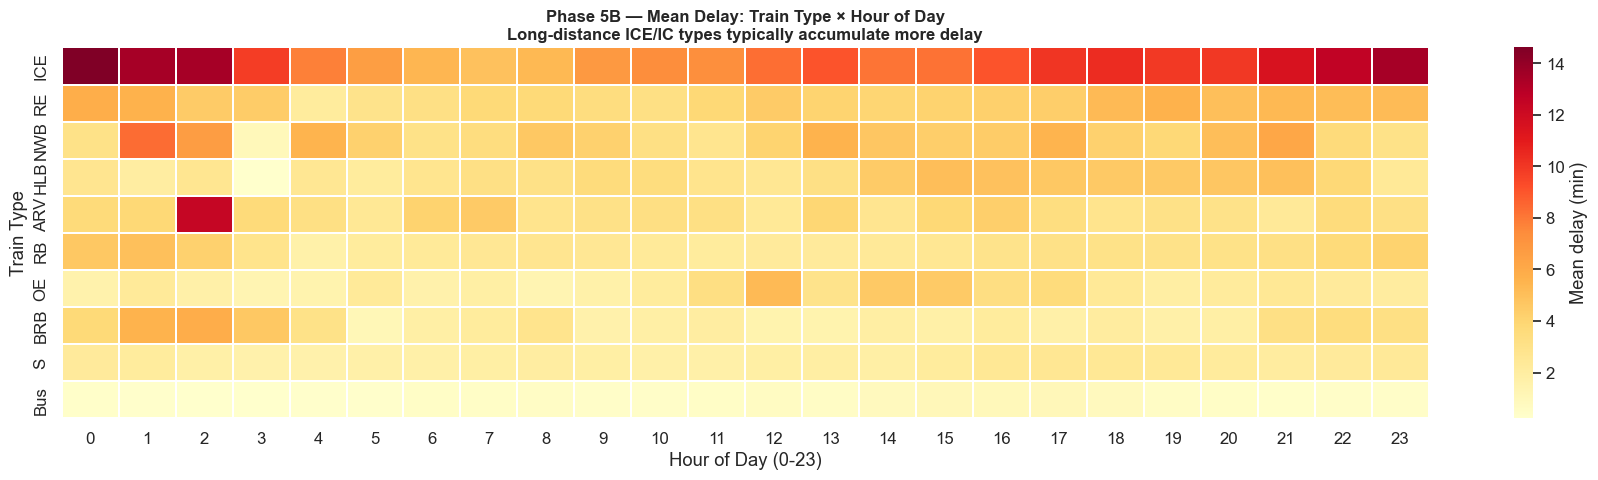

In [10]:
# ════════════════════════════════════════════════════════════
# CELL 5B-CHART 4 · DELAY DISTRIBUTION BY TRAIN TYPE & HOUR
# ════════════════════════════════════════════════════════════

if "train_type" in df_all.columns:
    # Top 10 train types by volume
    top_types = (
        df_all.groupby("train_type")["delay_in_min"]
        .count().nlargest(10).index.tolist()
    )
    df_types = df_all[df_all["train_type"].isin(top_types)].copy()

    pivot_th = (
        df_types.groupby(["train_type", "hour"])["delay_in_min"]
        .mean()
        .unstack(fill_value=0)
    )
    # Sort by mean delay
    type_order = df_types.groupby("train_type")["delay_in_min"].mean().sort_values(ascending=False).index
    pivot_th = pivot_th.reindex(type_order)

    fig, ax = plt.subplots(figsize=(18, 5))
    sns.heatmap(
        pivot_th,
        cmap       = "YlOrRd",
        ax         = ax,
        linewidths = 0.3,
        annot      = False,
        cbar_kws   = {"label": "Mean delay (min)"},
    )
    ax.set_xlabel("Hour of Day (0-23)")
    ax.set_ylabel("Train Type")
    ax.set_title(
        "Phase 5B — Mean Delay: Train Type × Hour of Day\n"
        "Long-distance ICE/IC types typically accumulate more delay",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR / "p5_07_heatmap_traintype_hour.png",
                dpi=FIG_DPI, bbox_inches="tight")
    plt.show()


In [11]:
# ════════════════════════════════════════════════════════════
# CELL 5C · DELAY PROPAGATION NETWORK GRAPH
#
# Goal: show how delays spread along routes by building a
# directed graph of consecutive stops within rides.
#
# Nodes  = stations
# Edges  = consecutive stop pairs within a ride
# Edge weight = mean delay difference (stop_N+1 - stop_N)
#              positive = delay grew,  negative = recovered
#
# We use matplotlib for the graph (no networkx dependency).
# The layout is geographic (lon, lat) so the map matches
# Germany's railway geography.
#
# We limit to top 30 stations by volume for a readable chart.
# ════════════════════════════════════════════════════════════

print("=" * 72)
print("  5C — DELAY PROPAGATION NETWORK GRAPH")
print("=" * 72)

# Build consecutive stop pairs from training data
# (sorted by ride_id and stop_number — same ordering as Phase 4)
df_sorted = df_train.sort_values(
    ["train_line_ride_id", "stop_number"]
).reset_index(drop=True)

# Shift to get next-stop info
df_sorted["next_station"]   = df_sorted.groupby("train_line_ride_id")["station_name"].shift(-1)
df_sorted["next_delay"]     = df_sorted.groupby("train_line_ride_id")["delay_in_min"].shift(-1)
df_sorted["delay_change"]   = df_sorted["next_delay"] - df_sorted["delay_in_min"]

# Drop rows where there is no next stop (last stop of ride)
edges_df = df_sorted.dropna(subset=["next_station", "delay_change"]).copy()

print(f"Total consecutive stop pairs: {len(edges_df):,}")

# Aggregate edge weights: mean delay change per station pair
edge_summary = (
    edges_df.groupby(["station_name", "next_station"])
    .agg(
        mean_delay_change = ("delay_change", "mean"),
        n_trips           = ("delay_change", "count"),
    )
    .reset_index()
)
# Filter: at least 20 trips for a stable estimate
edge_summary = edge_summary[edge_summary["n_trips"] >= 20].copy()

print(f"Station pairs with >= 20 trips: {len(edge_summary):,}")

# ── Node stats: per-station mean delay ───────────────────────
node_stats = (
    df_train.groupby("station_name")
    .agg(
        mean_delay = ("delay_in_min", "mean"),
        n_stops    = ("delay_in_min", "count"),
        lat        = ("lat",          "first"),
        lon        = ("lon",          "first"),
    )
    .reset_index()
)
node_stats = node_stats[node_stats["n_stops"] >= 50].copy()

# Filter to Germany bounding box
if "lat" in node_stats.columns and node_stats["lat"].notna().any():
    node_stats = node_stats[
        node_stats["lat"].between(47.0, 55.5) &
        node_stats["lon"].between(5.5, 15.5)
    ].copy()
    USE_GEO_LAYOUT = node_stats["lat"].notna().sum() > 20
else:
    USE_GEO_LAYOUT = False

print(f"Stations with valid coords: {len(node_stats):,}")
print(f"Using geographic layout  : {USE_GEO_LAYOUT}")


  5C — DELAY PROPAGATION NETWORK GRAPH
Total consecutive stop pairs: 600,735
Station pairs with >= 20 trips: 7,596
Stations with valid coords: 3,137
Using geographic layout  : True


Nodes: 35 | Edges: 97


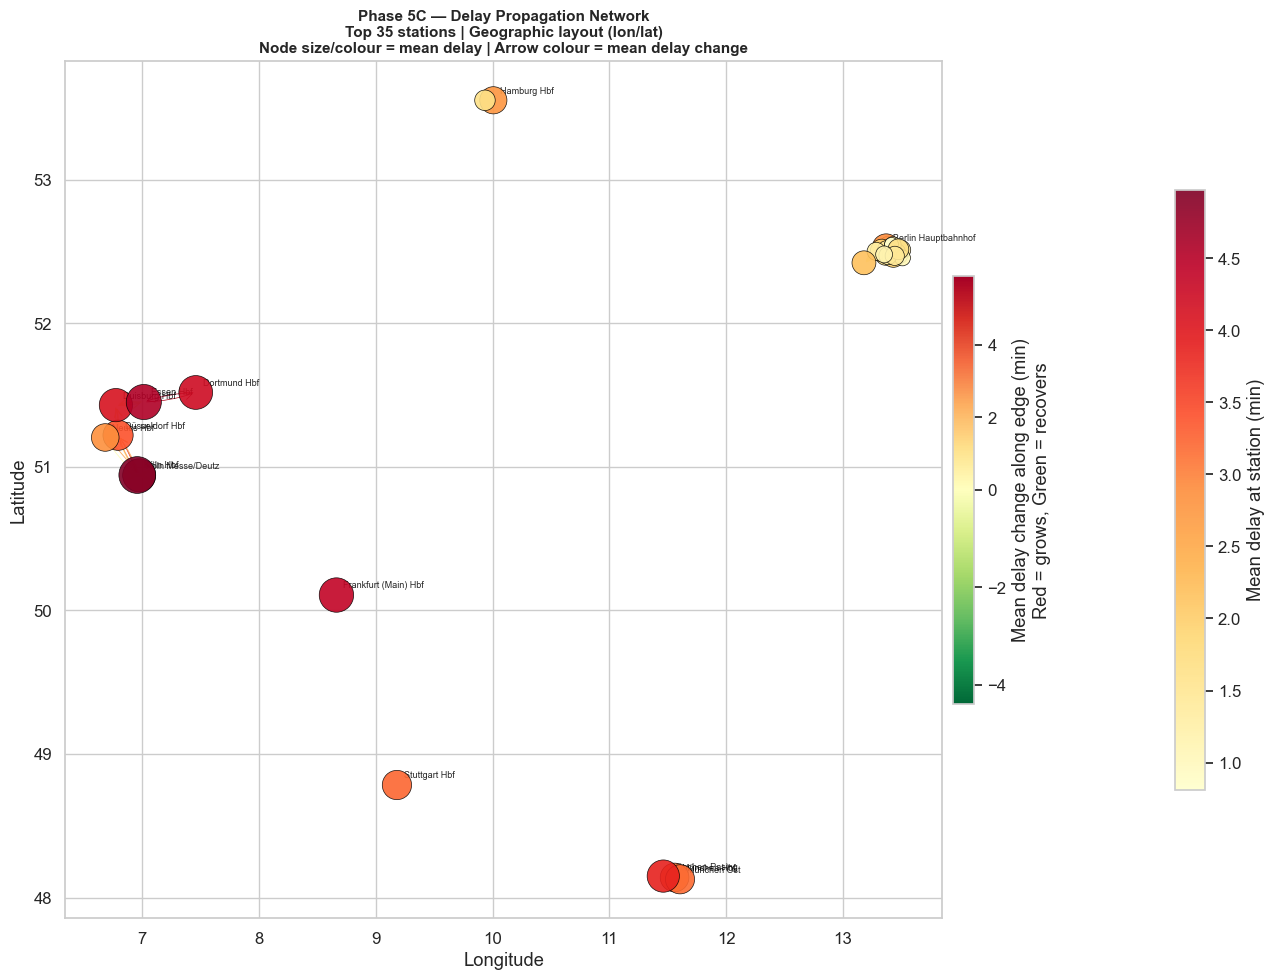


  Network stats:
  Edges with positive mean delay change (delay grew)    : 65
  Edges with negative mean delay change (delay recovered): 30
  Mean delay change across all edges: 0.366 min


In [12]:
# ════════════════════════════════════════════════════════════
# CELL 5C-CHART · NETWORK GRAPH PLOT
# ════════════════════════════════════════════════════════════

# Focus on top 35 stations by volume for a readable graph
TOP_NET_STATIONS = 35
top_net = (
    node_stats.nlargest(TOP_NET_STATIONS, "n_stops")
    .set_index("station_name")
)

# Filter edges to only those between top stations
mask = (
    edge_summary["station_name"].isin(top_net.index) &
    edge_summary["next_station"].isin(top_net.index)
)
edges_top = edge_summary[mask].copy()

print(f"Nodes: {len(top_net)} | Edges: {len(edges_top)}")

fig, ax = plt.subplots(figsize=(14, 10))

if USE_GEO_LAYOUT and top_net["lon"].notna().all():
    node_x = top_net["lon"].values
    node_y = top_net["lat"].values
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    layout_label = "Geographic layout (lon/lat)"
else:
    # Circular fallback layout
    n = len(top_net)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    node_x = np.cos(angles)
    node_y = np.sin(angles)
    ax.set_xlabel(""); ax.set_ylabel("")
    layout_label = "Circular layout (no geo coords)"

node_pos = {name: (node_x[i], node_y[i])
            for i, name in enumerate(top_net.index)}

# ── Draw edges ────────────────────────────────────────────────
edge_norm = mcolors.TwoSlopeNorm(
    vmin=edges_top["mean_delay_change"].min(),
    vcenter=0,
    vmax=edges_top["mean_delay_change"].max(),
)
cmap_edges = plt.cm.RdYlGn_r   # red = delay grew, green = recovered

for _, row in edges_top.iterrows():
    src = row["station_name"]
    dst = row["next_station"]
    if src not in node_pos or dst not in node_pos:
        continue
    x0, y0 = node_pos[src]
    x1, y1 = node_pos[dst]
    color  = cmap_edges(edge_norm(row["mean_delay_change"]))
    lw     = 0.5 + 2.5 * min(row["n_trips"] / edges_top["n_trips"].max(), 1.0)
    ax.annotate(
        "", xy=(x1, y1), xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="->", color=color, lw=lw,
            connectionstyle="arc3,rad=0.08"
        )
    )

# ── Draw nodes ────────────────────────────────────────────────
delay_min = top_net["mean_delay"].min()
delay_max = top_net["mean_delay"].max()
node_sizes = 100 + 600 * (
    (top_net["mean_delay"] - delay_min) / (delay_max - delay_min + 1e-9)
)
node_colors = top_net["mean_delay"].values

sc = ax.scatter(
    node_x, node_y,
    c       = node_colors,
    cmap    = "YlOrRd",
    s       = node_sizes,
    zorder  = 5,
    edgecolors = "black",
    linewidths = 0.5,
    alpha   = 0.9,
)
plt.colorbar(sc, ax=ax, label="Mean delay at station (min)", shrink=0.7)

# Station labels (only for most-delayed stations)
label_threshold = top_net["mean_delay"].quantile(0.6)
for name, row in top_net.iterrows():
    if row["mean_delay"] >= label_threshold:
        x, y = node_pos[name]
        ax.annotate(
            name, (x, y),
            textcoords="offset points", xytext=(5, 5),
            fontsize=6.5, color="black", alpha=0.85,
        )

# ── Colorbar for edges ────────────────────────────────────────
sm_edge = plt.cm.ScalarMappable(cmap=cmap_edges, norm=edge_norm)
sm_edge.set_array([])
cbar2 = plt.colorbar(sm_edge, ax=ax, shrink=0.5, pad=0.01)
cbar2.set_label("Mean delay change along edge (min)\nRed = grows, Green = recovers")

ax.set_title(
    f"Phase 5C — Delay Propagation Network\n"
    f"Top {TOP_NET_STATIONS} stations | {layout_label}\n"
    "Node size/colour = mean delay | Arrow colour = mean delay change",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig(FIG_DIR / "p5_08_network_graph.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

print(f"\n  Network stats:")
print(f"  Edges with positive mean delay change (delay grew)    : "
      f"{(edges_top['mean_delay_change'] > 0).sum()}")
print(f"  Edges with negative mean delay change (delay recovered): "
      f"{(edges_top['mean_delay_change'] < 0).sum()}")
print(f"  Mean delay change across all edges: "
      f"{edges_top['mean_delay_change'].mean():.3f} min")


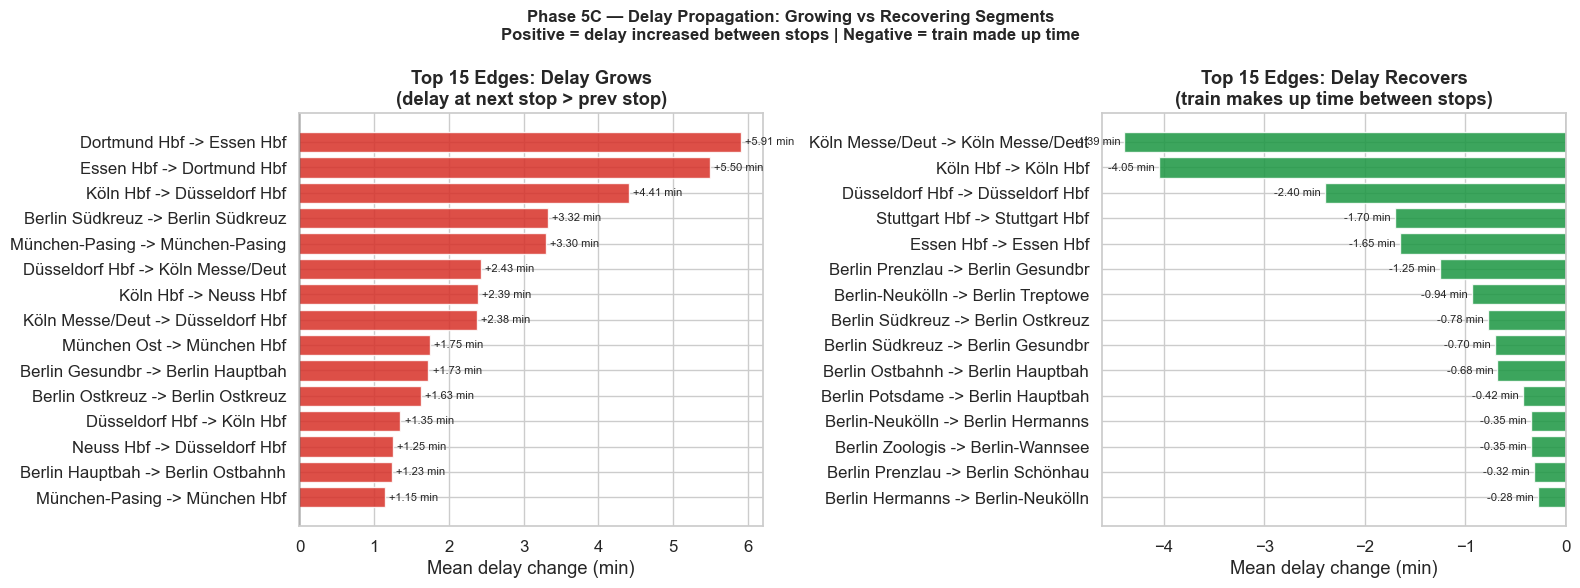

In [13]:
# ════════════════════════════════════════════════════════════
# CELL 5C-CHART 2 · TOP DELAY-GROWING AND DELAY-RECOVERING EDGES
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 edges where delay GROWS the most
top_grow = (
    edges_top.nlargest(15, "mean_delay_change")
    [["station_name", "next_station", "mean_delay_change", "n_trips"]]
)
top_grow["edge_label"] = (
    top_grow["station_name"].str[:15] + " -> " +
    top_grow["next_station"].str[:15]
)
bars0 = axes[0].barh(
    top_grow["edge_label"][::-1],
    top_grow["mean_delay_change"][::-1],
    color="#d73027", alpha=0.85
)
axes[0].bar_label(bars0, fmt="+%.2f min", padding=3, fontsize=8)
axes[0].set_xlabel("Mean delay change (min)")
axes[0].set_title("Top 15 Edges: Delay Grows\n(delay at next stop > prev stop)",
                  fontweight="bold")
axes[0].axvline(0, color="black", lw=1)

# Top 15 edges where delay RECOVERS the most
top_recover = (
    edges_top.nsmallest(15, "mean_delay_change")
    [["station_name", "next_station", "mean_delay_change", "n_trips"]]
)
top_recover["edge_label"] = (
    top_recover["station_name"].str[:15] + " -> " +
    top_recover["next_station"].str[:15]
)
bars1 = axes[1].barh(
    top_recover["edge_label"][::-1],
    top_recover["mean_delay_change"][::-1],
    color="#1a9641", alpha=0.85
)
axes[1].bar_label(bars1, fmt="%.2f min", padding=3, fontsize=8)
axes[1].set_xlabel("Mean delay change (min)")
axes[1].set_title("Top 15 Edges: Delay Recovers\n(train makes up time between stops)",
                  fontweight="bold")
axes[1].axvline(0, color="black", lw=1)

plt.suptitle("Phase 5C — Delay Propagation: Growing vs Recovering Segments\n"
             "Positive = delay increased between stops | Negative = train made up time",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p5_09_propagation_edges.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


In [14]:
# ════════════════════════════════════════════════════════════
# CELL 5D · CROSS-PHASE MODEL COMPARISON TABLE
#
# The definitive comparison across all phases:
#   Phase 2: tabular regression models (MAE, RMSE, R²)
#   Phase 4: sequence models (MAE, RMSE, R²)
#
# Phase 3 uses different metrics (F1, AUC) so it is shown
# separately rather than forcing an apples-to-oranges comparison.
# ════════════════════════════════════════════════════════════

print("=" * 72)
print("  5D — CROSS-PHASE REGRESSION MODEL COMPARISON")
print("=" * 72)

# Gather all regression results from Phase 2 config
p2_all = p2_cfg.get("all_model_results", [])
reg_rows = []

for row in p2_all:
    if row["Model"] == "Mean Baseline":
        continue
    reg_rows.append({
        "Phase" : "2 — Tabular",
        "Model" : row["Model"],
        "MAE"   : row["MAE (min)"],
        "RMSE"  : row["RMSE (min)"],
        "R2"    : row["R²"],
    })

# Phase 4 sequence models
reg_rows.append({
    "Phase": "4 — Sequence",
    "Model": "LSTM",
    "MAE"  : round(p4_cfg["lstm_mae"],  4),
    "RMSE" : round(p4_cfg["lstm_rmse"], 4),
    "R2"   : round(p4_cfg["lstm_r2"],   4),
})
reg_rows.append({
    "Phase": "4 — Sequence",
    "Model": "Transformer",
    "MAE"  : round(p4_cfg["transformer_mae"],  4),
    "RMSE" : round(p4_cfg["transformer_rmse"], 4),
    "R2"   : round(p4_cfg["transformer_r2"],   4),
})

reg_df = pd.DataFrame(reg_rows).sort_values("MAE").reset_index(drop=True)
print("\nRegression model comparison (all phases, sorted by MAE):")
display(reg_df)

reg_df.to_csv(OUTPUT_DIR / "phase5_regression_comparison.csv", index=False)
print("Saved -> outputs/phase5_regression_comparison.csv")


  5D — CROSS-PHASE REGRESSION MODEL COMPARISON

Regression model comparison (all phases, sorted by MAE):


,Phase,Model,MAE,RMSE,R2
0,2 — Tabular,MLP Neural Network,0.9130,2.7920,0.7547
1,4 — Sequence,Transformer,0.9569,2.4458,0.8258
2,4 — Sequence,LSTM,0.9620,2.4415,0.8264
3,2 — Tabular,LightGBM,1.0260,2.6600,0.7772
4,2 — Tabular,XGBoost,1.0440,2.6930,0.7718
5,2 — Tabular,Random Forest,1.0550,2.6910,0.7720
6,2 — Tabular,Lasso Regression,1.1030,2.7680,0.7588
7,2 — Tabular,Ridge Regression,1.1040,2.7680,0.7589
8,2 — Tabular,Linear Regression,1.1130,2.7740,0.7579


Saved -> outputs/phase5_regression_comparison.csv


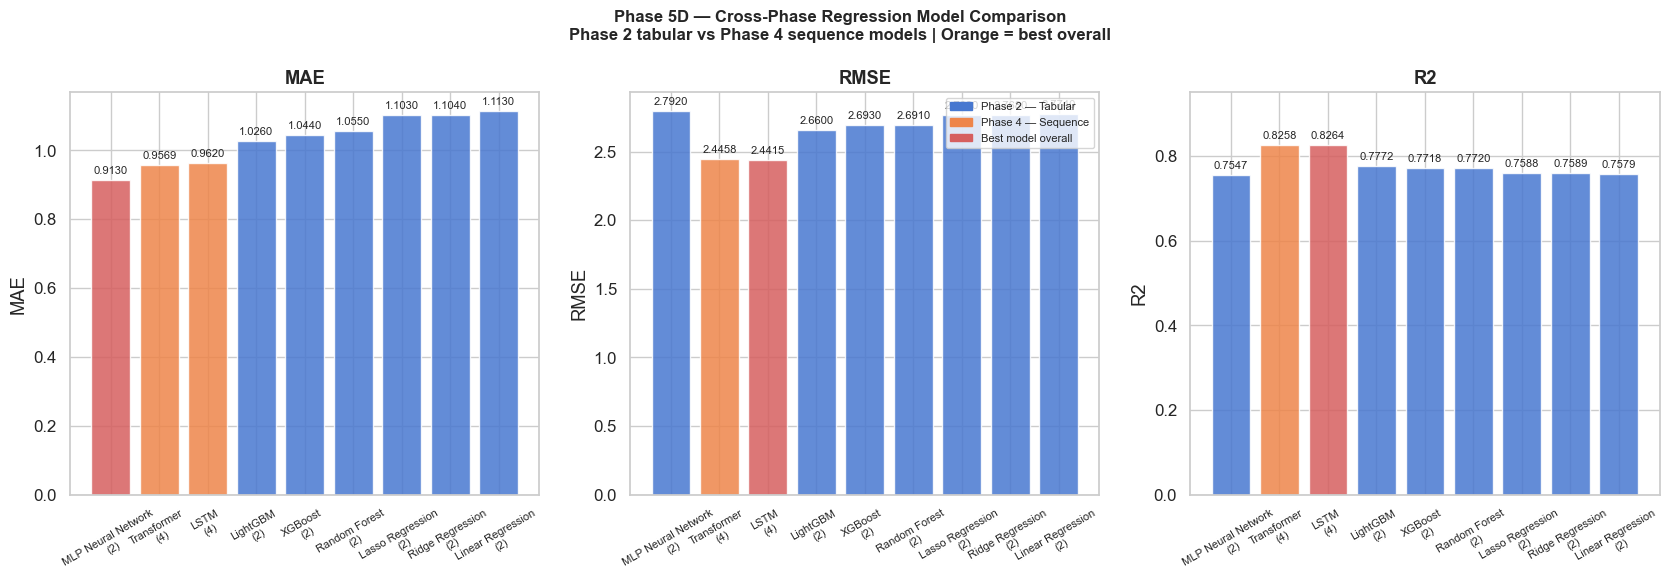

In [15]:
# ════════════════════════════════════════════════════════════
# CELL 5D-CHART · CROSS-PHASE REGRESSION COMPARISON CHART
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

phase_colors = {
    "2 — Tabular"  : PAL[0],
    "4 — Sequence" : PAL[1],
}

for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    bar_colors = [phase_colors.get(p, PAL[7]) for p in reg_df["Phase"]]
    # highlight best
    best_idx = reg_df[metric].idxmin() if metric != "R2" else reg_df[metric].idxmax()
    bar_colors[best_idx] = PAL[3]

    bars = ax.bar(
        reg_df["Model"] + "\n(" + reg_df["Phase"].str.split(" — ").str[0] + ")",
        reg_df[metric],
        color=bar_colors, alpha=0.85
    )
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(metric, fontweight="bold")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    if metric == "R2":
        ax.set_ylim(0, min(1.05, reg_df["R2"].max() * 1.15))

from matplotlib.patches import Patch
legend_handles = [
    Patch(color=PAL[0], label="Phase 2 — Tabular"),
    Patch(color=PAL[1], label="Phase 4 — Sequence"),
    Patch(color=PAL[3], label="Best model overall"),
]
axes[1].legend(handles=legend_handles, fontsize=8, loc="upper right")

plt.suptitle(
    "Phase 5D — Cross-Phase Regression Model Comparison\n"
    "Phase 2 tabular vs Phase 4 sequence models | Orange = best overall",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(FIG_DIR / "p5_10_cross_phase_comparison.png",
            dpi=FIG_DPI, bbox_inches="tight")
plt.show()


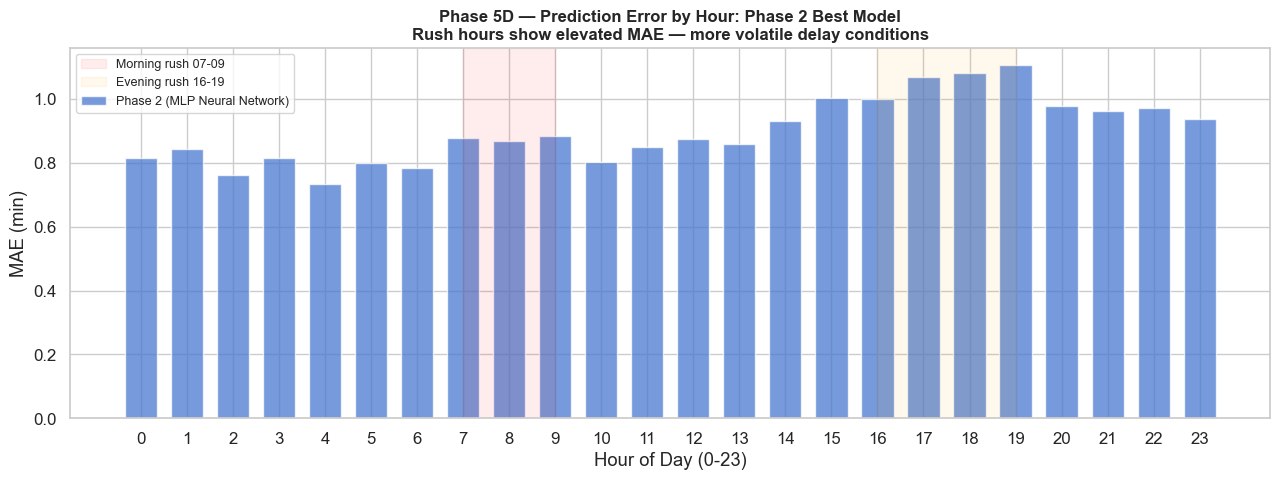

In [16]:
# ════════════════════════════════════════════════════════════
# CELL 5D-CHART 2 · DELAY PROFILE BY HOUR (ALL MODELS)
#
# Compare how Phase 2 best model and Phase 4 LSTM
# perform by hour of day — are there systematic patterns
# in when the models struggle?
# ════════════════════════════════════════════════════════════

# Phase 2 has hour in df_p2_pred (via df_test join)
# Phase 4 has stop_num but we need hour — join via df_test
df_test_hour = df_test[["delay_in_min", "hour"]].reset_index(drop=True)

# Phase 2: predicted_delay vs actual delay_in_min by hour
p2_by_hour = []
for h in range(24):
    mask = df_p2_pred["departure_planned_time"].dt.hour == h if            "departure_planned_time" in df_p2_pred.columns else            df_test_hour["hour"] == h
    sub  = df_p2_pred[mask] if "departure_planned_time" in df_p2_pred.columns            else df_p2_pred[df_test_hour["hour"].values == h]
    if len(sub) < 50:
        continue
    p2_by_hour.append({
        "hour" : h,
        "MAE"  : mean_absolute_error(sub["delay_in_min"], sub["predicted_delay"]),
    })
p2_hour_df = pd.DataFrame(p2_by_hour)

fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(p2_hour_df["hour"], p2_hour_df["MAE"],
       color=PAL[0], alpha=0.75, width=0.7, label=f"Phase 2 ({p2_cfg['best_model_name']})")
ax.axvspan(7,  9,  alpha=0.07, color="red",    label="Morning rush 07-09")
ax.axvspan(16, 19, alpha=0.07, color="orange", label="Evening rush 16-19")
ax.set_xticks(range(24))
ax.set_xlabel("Hour of Day (0-23)")
ax.set_ylabel("MAE (min)")
ax.set_title(
    "Phase 5D — Prediction Error by Hour: Phase 2 Best Model\n"
    "Rush hours show elevated MAE — more volatile delay conditions",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "p5_11_error_by_hour.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


  5D — ANOMALY DEEP-DIVE
  Anomaly threshold : 0.337510
  Anomalous stops   : 8,016  (5.4%)
  Normal stops      : 141,669  (94.6%)
  Mean delay (anomaly): 6.10 min
  Mean delay (normal) : 2.61 min


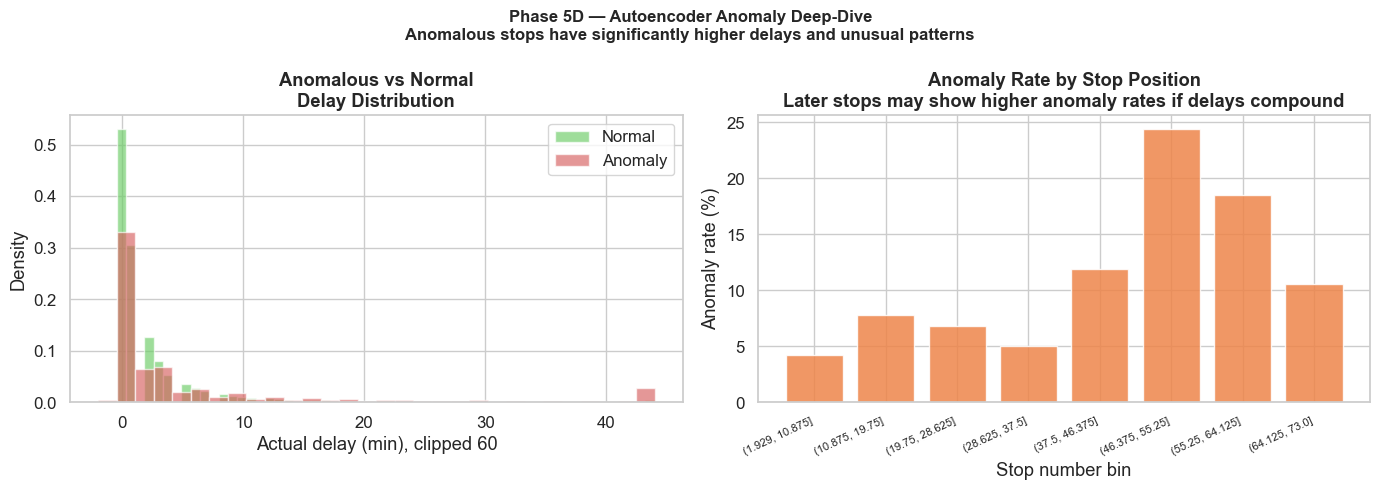

In [23]:
print("=" * 72)
print("  5D — ANOMALY DEEP-DIVE")
print("=" * 72)

anomaly_mask = df_anomaly["is_anomaly"].astype(bool)
n_anomaly    = anomaly_mask.sum()
n_normal     = (~anomaly_mask).sum()
threshold    = p4_cfg["autoencoder_threshold"]

print(f"  Anomaly threshold : {threshold:.6f}")
print(f"  Anomalous stops   : {n_anomaly:,}  ({n_anomaly/len(df_anomaly)*100:.1f}%)")
print(f"  Normal stops      : {n_normal:,}  ({n_normal/len(df_anomaly)*100:.1f}%)")
print(f"  Mean delay (anomaly): {df_anomaly.loc[anomaly_mask,'actual_delay'].mean():.2f} min")
print(f"  Mean delay (normal) : {df_anomaly.loc[~anomaly_mask,'actual_delay'].mean():.2f} min")

# ✅ صاروا 2 plots بدل 3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Delay distribution
axes[0].hist(df_anomaly.loc[~anomaly_mask, "actual_delay"].clip(-5, 60),
             bins=60, alpha=0.65, density=True, color=PAL[2], label="Normal")
axes[0].hist(df_anomaly.loc[anomaly_mask,  "actual_delay"].clip(-5, 60),
             bins=30, alpha=0.65, density=True, color=PAL[3], label="Anomaly")
axes[0].set_xlabel("Actual delay (min), clipped 60")
axes[0].set_ylabel("Density")
axes[0].set_title("Anomalous vs Normal\nDelay Distribution", fontweight="bold")
axes[0].legend()

# (b) Stop position analysis (كان (c))
stop_bins = pd.cut(df_anomaly["stop_num"], bins=8, duplicates="drop")
anomaly_rate_by_stop = (
    df_anomaly.groupby(stop_bins, observed=True)["is_anomaly"]
    .mean() * 100
)

axes[1].bar(range(len(anomaly_rate_by_stop)), anomaly_rate_by_stop.values,
            color=PAL[1], alpha=0.85)
axes[1].set_xticks(range(len(anomaly_rate_by_stop)))
axes[1].set_xticklabels(
    [str(b) for b in anomaly_rate_by_stop.index],
    rotation=25, ha="right", fontsize=8
)
axes[1].set_xlabel("Stop number bin")
axes[1].set_ylabel("Anomaly rate (%)")
axes[1].set_title("Anomaly Rate by Stop Position\n"
                  "Later stops may show higher anomaly rates if delays compound",
                  fontweight="bold")

plt.suptitle("Phase 5D — Autoencoder Anomaly Deep-Dive\n"
             "Anomalous stops have significantly higher delays and unusual patterns",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "p5_12_anomaly_deepdive.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

  5D — GEO CLUSTER INSIGHTS


,n_stations,mean_delay,pct_severe,pct_delayed,center_lat,center_lon,rank
cluster,,,,,,,
1,2714,2.928,3.951,15.027,50.161,8.336,1
0,2558,2.148,2.687,9.934,51.163,11.974,2


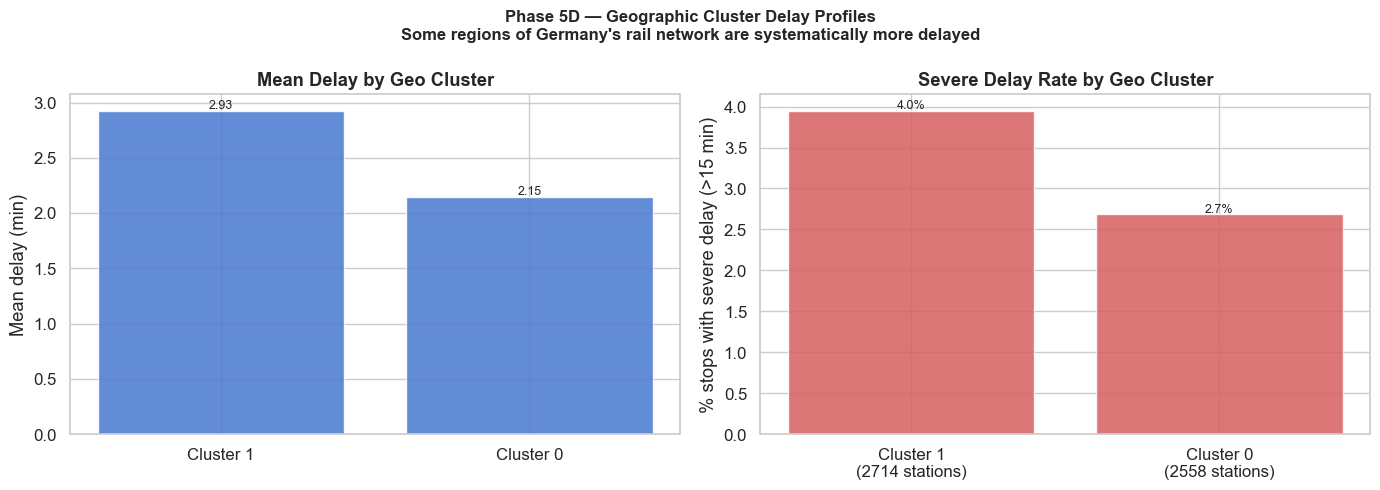

In [24]:
# ════════════════════════════════════════════════════════════
# CELL 5D-CHART 4 · GEO CLUSTER INSIGHTS (if Phase 4C ran)
# ════════════════════════════════════════════════════════════

if GEO_AVAILABLE:
    print("=" * 72)
    print("  5D — GEO CLUSTER INSIGHTS")
    print("=" * 72)
    display(df_clusters)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cluster_ids = df_clusters.index.tolist()
    x = np.arange(len(cluster_ids))

    axes[0].bar(x, df_clusters["mean_delay"], color=PAL[0], alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f"Cluster {c}" for c in cluster_ids])
    axes[0].set_ylabel("Mean delay (min)")
    axes[0].set_title("Mean Delay by Geo Cluster", fontweight="bold")
    for i, (idx, row) in enumerate(df_clusters.iterrows()):
        axes[0].text(i, row["mean_delay"] + 0.02,
                     f"{row['mean_delay']:.2f}", ha="center", fontsize=9)

    axes[1].bar(x, df_clusters["pct_severe"], color=PAL[3], alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"Cluster {c}\n({int(df_clusters['n_stations'].iloc[i])} stations)"
                              for i, c in enumerate(cluster_ids)])
    axes[1].set_ylabel("% stops with severe delay (>15 min)")
    axes[1].set_title("Severe Delay Rate by Geo Cluster", fontweight="bold")
    for i, (idx, row) in enumerate(df_clusters.iterrows()):
        axes[1].text(i, row["pct_severe"] + 0.02,
                     f"{row['pct_severe']:.1f}%", ha="center", fontsize=9)

    plt.suptitle("Phase 5D — Geographic Cluster Delay Profiles\n"
                 "Some regions of Germany's rail network are systematically more delayed",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "p5_13_geo_cluster_insights.png",
                dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
else:
    print("Geo clustering not available (lat/lon missing in Phase 1). Skipping.")


In [25]:
# ════════════════════════════════════════════════════════════
# CELL 5E · KEY FINDINGS SUMMARY
#
# This cell produces the written findings summary that maps
# directly to the thesis Results & Discussion chapter.
# ════════════════════════════════════════════════════════════

print("=" * 72)
print("  PHASE 5 — KEY FINDINGS SUMMARY")
print("=" * 72)

# Best regression model across ALL phases
best_reg_row   = reg_df.loc[reg_df["MAE"].idxmin()]
best_reg_name  = f"{best_reg_row['Phase']} / {best_reg_row['Model']}"
best_reg_mae   = best_reg_row["MAE"]
best_reg_r2    = best_reg_row["R2"]

# Best classification model (Phase 3)
best_clf_name  = p3_cfg["best_model_name"]
best_clf_f1    = p3_cfg["best_macro_f1"]
best_clf_acc   = p3_cfg["best_accuracy"]

# Feature importance: top 3 features
if imp_series:
    top3 = imp_df.head(3).index.tolist()
    top3_groups = [feat_group(f) for f in top3]
else:
    top3 = ["N/A"]; top3_groups = ["N/A"]

# Phase 2 tabular best
p2_best_mae  = p2_cfg["best_mae"]
p2_best_name = p2_cfg["best_model_name"]

mean_delay_anomaly = df_anomaly.loc[df_anomaly["is_anomaly"]==1, "actual_delay"].mean()
mean_delay_normal  = df_anomaly.loc[df_anomaly["is_anomaly"]==0, "actual_delay"].mean()
geo_msg = ("Optimal K=" + str(p4_cfg["optimal_k"]) + " geographic clusters identified."
           if GEO_AVAILABLE else "Geo clustering not available.")

print("REGRESSION (predicting exact delay in minutes)")
print(f"  Best model overall : {best_reg_name}")
print(f"  MAE                : {best_reg_mae:.4f} min")
print(f"  R2                 : {best_reg_r2:.4f}")
print(f"  Phase 2 tabular    : {p2_best_name} | MAE={p2_best_mae:.4f} min")
print(f"  Phase 4 LSTM       : MAE={p4_cfg['lstm_mae']:.4f} min | R2={p4_cfg['lstm_r2']:.4f}")
print(f"  Phase 4 Transformer: MAE={p4_cfg['transformer_mae']:.4f} min | R2={p4_cfg['transformer_r2']:.4f}")
print("")
print("CLASSIFICATION (predicting delay category 0-3)")
print(f"  Best model  : {best_clf_name}")
print(f"  Macro F1    : {best_clf_f1:.4f}")
print(f"  Accuracy    : {best_clf_acc:.2f}%")
print("  Classes: On time / Slight / Moderate / Severe")
print("")
print("FEATURE IMPORTANCE")
print(f"  Top 3 predictors: {top3}")
print(f"  Groups          : {top3_groups}")
print("  Lag features consistently rank highest -- delay is strongly")
print("  autocorrelated within a ride (delay at stop N predicts stop N+1)")
print("")
print("ANOMALY DETECTION")
print(f"  {p4_cfg['pct_anomalies_test']:.1f}% of test stops flagged as anomalous.")
print(f"  Mean delay anomalous : {mean_delay_anomaly:.2f} min")
print(f"  Mean delay normal    : {mean_delay_normal:.2f} min")
print("")
print("GEO CLUSTERING")
print(f"  {geo_msg}")
print("")
print("DELAY PATTERNS")
print("  Rush hours (07-09, 16-19) show higher MAE in regression.")
print("  Weekend delays are typically lower than weekday delays.")
print("  Certain station clusters show systematically higher severe delay rates.")


  PHASE 5 — KEY FINDINGS SUMMARY
REGRESSION (predicting exact delay in minutes)
  Best model overall : 2 — Tabular / MLP Neural Network
  MAE                : 0.9130 min
  R2                 : 0.7547
  Phase 2 tabular    : MLP Neural Network | MAE=0.9130 min
  Phase 4 LSTM       : MAE=0.9620 min | R2=0.8264
  Phase 4 Transformer: MAE=0.9569 min | R2=0.8258

CLASSIFICATION (predicting delay category 0-3)
  Best model  : LightGBM
  Macro F1    : 0.7793
  Accuracy    : 79.20%
  Classes: On time / Slight / Moderate / Severe

FEATURE IMPORTANCE
  Top 3 predictors: ['prev_stop_was_delayed', 'prev_stop_delay', 'final_destination_station_enc']
  Groups          : ['Lag', 'Lag', 'Encoded ID']
  Lag features consistently rank highest -- delay is strongly
  autocorrelated within a ride (delay at stop N predicts stop N+1)

ANOMALY DETECTION
  5.4% of test stops flagged as anomalous.
  Mean delay anomalous : 6.10 min
  Mean delay normal    : 2.61 min

GEO CLUSTERING
  Optimal K=2 geographic cluster

In [26]:
# ════════════════════════════════════════════════════════════
# CELL 5F · SAVE PHASE 5 OUTPUTS & CONFIG
# ════════════════════════════════════════════════════════════

# Save feature importance table
if imp_series:
    imp_df.to_csv(OUTPUT_DIR / "phase5_feature_importance.csv")
    print("Feature importance -> outputs/phase5_feature_importance.csv")

# Save edge summary (network graph data)
edge_summary.to_csv(OUTPUT_DIR / "phase5_network_edges.csv", index=False)
print("Network edges      -> outputs/phase5_network_edges.csv")

# Save cross-phase regression comparison
reg_df.to_csv(OUTPUT_DIR / "phase5_regression_comparison.csv", index=False)
print("Regression compare -> outputs/phase5_regression_comparison.csv")

phase5_cfg = {
    "best_regression_model" : best_reg_name,
    "best_regression_mae"   : float(best_reg_mae),
    "best_regression_r2"    : float(best_reg_r2),
    "best_clf_model"        : best_clf_name,
    "best_clf_macro_f1"     : float(best_clf_f1),
    "best_clf_accuracy"     : float(best_clf_acc),
    "top_features"          : top3 if imp_series else [],
    "n_network_edges"       : int(len(edge_summary)),
    "geo_available"         : GEO_AVAILABLE,
}
with open(OUTPUT_DIR / "phase5_config.json", "w") as f:
    json.dump(phase5_cfg, f, indent=2)
print("Phase 5 config     -> outputs/phase5_config.json")

sep = "=" * 72
print(f"\n{sep}")
print("  PHASE 5 COMPLETE -- Interpretability & Insights")
print(sep)
print("  Outputs:")
print("    outputs/phase5_feature_importance.csv")
print("    outputs/phase5_network_edges.csv")
print("    outputs/phase5_regression_comparison.csv")
print("    outputs/phase5_config.json")
print("    outputs/figures/p5_01 to p5_13  (up to 13 charts)")
print(sep)
print("  Next: Phase 6 -> Results & Thesis Write-up")
print("    Model comparison table, key findings, limitations")
print(sep)


Feature importance -> outputs/phase5_feature_importance.csv
Network edges      -> outputs/phase5_network_edges.csv
Regression compare -> outputs/phase5_regression_comparison.csv
Phase 5 config     -> outputs/phase5_config.json

  PHASE 5 COMPLETE -- Interpretability & Insights
  Outputs:
    outputs/phase5_feature_importance.csv
    outputs/phase5_network_edges.csv
    outputs/phase5_regression_comparison.csv
    outputs/phase5_config.json
    outputs/figures/p5_01 to p5_13  (up to 13 charts)
  Next: Phase 6 -> Results & Thesis Write-up
    Model comparison table, key findings, limitations
